In [35]:
#Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
#Load the dataset
file_path = "/content/Phishing_Email.csv"

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [37]:
#Get dataset shape
df = pd.read_csv(file_path, on_bad_lines="skip")
print(df.shape)

(18650, 3)


In [38]:
#Get basic dataset structure
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())


Columns:
['Unnamed: 0', 'Email Text', 'Email Type']

Data types:
Unnamed: 0     int64
Email Text    object
Email Type    object
dtype: object

First 5 rows:


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [39]:
#Get the target label from dataset
print("Email type distribution:")
print(df["Email Type"].value_counts())

print("\nPercentage distribution:")
print(df["Email Type"].value_counts(normalize=True) * 100)

Email type distribution:
Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

Percentage distribution:
Email Type
Safe Email        60.707775
Phishing Email    39.292225
Name: proportion, dtype: float64


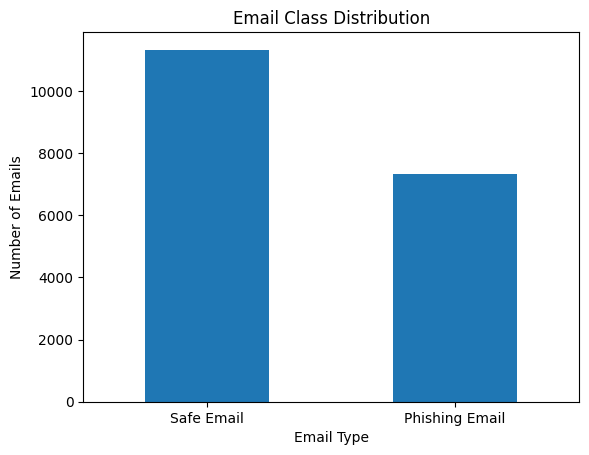

In [40]:
#Check data imbalance
df["Email Type"].value_counts().plot(kind="bar")

plt.title("Email Class Distribution")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()

In [41]:
#Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64


In [42]:
#Check empty email text
email_col = "Email Text"

empty_emails = (
    df[email_col]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Empty email texts:", empty_emails)

Empty email texts: 19


In [43]:
#Check duplicate and different label
email_col = "Email Text"
duplicate_count = df[email_col].duplicated().sum()

different_emailtype = (
    df.groupby(email_col)["Email Type"]
      .nunique()
)
different_label = (different_emailtype > 1).sum()

print("Duplicate email texts:", duplicate_count)
print("Emails with different label:", different_label)

Duplicate email texts: 1112
Emails with different label: 1


In [44]:
#Check email lenth
df["text_length_chars"] = (
    df[email_col]
    .fillna("")
    .astype(str)
    .str.len()
)
print(df["text_length_chars"].describe())

count    1.865000e+04
mean     2.753290e+03
std      1.248141e+05
min      0.000000e+00
25%      4.030000e+02
50%      8.800000e+02
75%      1.879750e+03
max      1.703669e+07
Name: text_length_chars, dtype: float64


In [45]:
#Check word count
df["word_count"] = (
    df[email_col]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)
print(df["word_count"].describe())

count    1.865000e+04
mean     5.347204e+02
std      2.583957e+04
min      0.000000e+00
25%      7.400000e+01
50%      1.590000e+02
75%      3.540000e+02
max      3.527576e+06
Name: word_count, dtype: float64


In [46]:
#Compare email length by class
print(
    df.groupby("Email Type")["word_count"]
      .describe()
)

                  count        mean           std  min   25%    50%    75%  \
Email Type                                                                   
Phishing Email   7328.0  301.189001    569.723535  0.0  68.0  136.0  290.0   
Safe Email      11322.0  685.870253  33160.236982  1.0  79.0  179.0  389.0   

                      max  
Email Type                 
Phishing Email    11625.0  
Safe Email      3527576.0  


In [47]:
#See the examples
for label in df["Email Type"].unique():
    print("=" * 100)
    print("CLASS:", label)
    print("=" * 100)

    sample = df[df["Email Type"] == label].sample(
        min(3, len(df[df["Email Type"] == label])),
        random_state=42
    )

    for i, text in enumerate(sample[email_col], 1):
        print(f"\n--- Example {i} ---")
        print(str(text)[:3000])

CLASS: Safe Email

--- Example 1 ---
Eirikur said:
> This incident is an interesting microcosm of how society and law develop.
> The women of this town are attempting to regulate competition.  The social 
> standards mechanisms (I expect that shame has already been tried) have 
> failed, so legal is next. The point could also be to hassle the sunbather for reasons not given in
the story.  The sunbather has probably pissed off the complainers in other
ways, too.Law and society are wholeheartedly trivial.  Big fuzzy concepts like
"sluts vs. moms" are convenient vehicles for petty disputes as often as
not.- Lucas

--- Example 2 ---
hpl noms for june 06 , 2000 ( see attached file : hplo 606 . xls ) - hplo 606 . xls

--- Example 3 ---
On Tue, Aug 13, 2002 at 12:48:18AM +0100, wintermute mentioned:
> How unimaginably difficult is this to do?  There are as far as I know,
> no Linux kernel hackers, nor distros that originate from this fair
> island right?  Right. Antefacto Embedded Linux...did

In [48]:
duplicate_groups = (
    df.groupby(email_col)["Email Type"]
      .agg(["count", "nunique"])
      .sort_values("count", ascending=False)
)

display(duplicate_groups.head(20))

,count,nunique
Email Text,,
empty,533,2
"calpine daily gas nomination > ricky a . archer fuel supply 700 louisiana , suite 2700 houston , texas 77002 713 - 830 - 8659 direct 713 - 830 - 8722 fax - calpine daily gas nomination 1 . doc",9,1
"\nÂ \nDear \n Homeowner,Â *6.25% \n 30 Yr Fixed Rate MortgageInterest \n rates are at their lowest point in 40 years! We help you find the \n best rate for your situation by matching your needs with hundreds \n of lenders! Home Improvement, Refinance, Second \n Mortgage, Home Equity Loans, and More! Even with less \n than perfect credit! Click Here for a Free Quote!\nLock \n In YOUR LOW FIXED RATE TODAY\n aNO \n COST OUT OF POCKET aNO \n OBLIGATION aFREE \n CONSULTATION aALL \n CREDIT GRADES ACCEPTED \nRates as low as \n 6.25% won't stay this low forever CLICK HERE Â \n * based on mortgage rate as of 5-15-02 as low as 6.25% see lender \n for details Â H\nApply \n now and one of our lending partners will get back to you within \n 48 hours.CLICK HERE!\nTo Be Removed Please ""Clicking \nHere"" .",8,1
"creditfixThank You,Your email address was obtained from a purchased \nlist, Reference # 1320-15000.Â Â If you wish to unsubscribe from this list, please \nClick here and enter your \nname into the remove box. If you have previously \nunsubscribed and are still receiving this message, you may email our \nAbuse Control Center, \nor call 1-888-763-2497, or write us at: NoSpam, 6484 Coral Way, \nMiami, FL, 33155"".\nÂ© 2002 Web Credit Inc. All Rights Reserved.\n",7,1
"\nHello I am your hot lil horny toy.\n I am the one you dream About,\n I am a very open minded person,\n Love to talk about and any subject.\n Fantasy is my way of life, \n Ultimate in sex play. Ummmmmmmmmmmmmm\n I am Wet and ready for you. It is not your looks but your imagination that matters most,\n With My sexy voice I can make your dream come true...\n \n Hurry Up! call me let me Cummmmm for you..........................\nTOLL-FREE: 1-877-451-TEEN (1-877-451-8336)For phone billing: 1-900-993-2582\n-- \n_______________________________________________\nSign-up for your own FREE Personalized E-mail at Mail.com\nhttp://www.mail.com/?sr=signup",7,1
"\nIf you are struggling with MS Access to manage your data, don't worry because Bill Gates agrees that ""Access is \nconfusing"". If you are finding that MS Excel is fine as a spreadsheet \nbut doesn't allow you to build custom applications and reports with your data - don't \n worry, there is an alternative. The good news is that 1 million customers have found a \n really good alternativeTry our \ndatabase software that does not make you feel like a dummy for free. Just email \nClick Here \n \n , to receive your free 30 day full \n working copy of our award winning database. then you can decide foryourself. See why PC World describes our product as being ""an \n elegant, powerful database \nthat is easier than Access""and why InfoWorld says our database ""leaves MS Access in the dust"".We have been in \n business since 1982 and are acknowledged as the leader in powerful BUT useabledatabases to solve your business and personal \n information management needs. With this \ndatabase you can easily: Manage scheduling, contacts, mailings \n Organize billing, invoicing, receivables, payables \n Track inventory, equipment and facilities \n Manage customer information, service, \n employee,medical, and school records \n Keep track and report on projects, maintenance andÂ Â much more... To \n be removed from this list Click Here",5,1
"A man endowed with a 7-8"" hammer is simply\n better equipped than a man with a 5-6""hammer. \nWould you rather havemore than enough to get the job done or fall short. It's totally upto you. Our Methods are guaranteed to increase your size by 1-3"" Come in here and see how\n",5,1
"New Web Technology\nUNLIMITED WEB CONFERENCING\nSubscribe to the Web Conference Center for only $40.00 per month!\n(Connects up to 15 participants at a time plus audio charges)\nManage your mee

In [49]:
print("========== DATASET INSPECTION REPORT ==========")

print(f"Total records: {len(df):,}")
print(f"Total columns: {len(df.columns)}")

print("\nClass distribution:")
print(df["Email Type"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print(f"\nDuplicate email texts: {df[email_col].duplicated().sum():,}")
print(f"Empty email texts: {empty_emails:,}")

print("\nEmail character length:")
print(df["text_length_chars"].describe())

print("\nEmail word count:")
print(df["word_count"].describe())

========== DATASET INSPECTION REPORT ==========
Total records: 18,650
Total columns: 5

Class distribution:
Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

Missing values:
Unnamed: 0            0
Email Text           16
Email Type            0
text_length_chars     0
word_count            0
dtype: int64

Duplicate email texts: 1,112
Empty email texts: 19

Email character length:
count    1.865000e+04
mean     2.753290e+03
std      1.248141e+05
min      0.000000e+00
25%      4.030000e+02
50%      8.800000e+02
75%      1.879750e+03
max      1.703669e+07
Name: text_length_chars, dtype: float64

Email word count:
count    1.865000e+04
mean     5.347204e+02
std      2.583957e+04
min      0.000000e+00
25%      7.400000e+01
50%      1.590000e+02
75%      3.540000e+02
max      3.527576e+06
Name: word_count, dtype: float64
